## For MADWA project this file reads the Wannier90 Hamiltonian, calculates bands and compares them with Wannier90_bands 

In [1]:
# Import libraries
import numpy as np
import numpy.linalg as la
import matplotlib.pyplot as plt
import numba as nb

import os
import sys
script_dir = os.path.dirname(os.path.abspath('__file__'))
project_root = os.path.abspath(os.path.join(script_dir, '..','Src'))  # adjust '..' depending where you are
sys.path.insert(0, project_root)

## Direct comparison with Wannier90 bands.dat 

In [2]:
import MadWa.Tbasic.tbasic as tbasic
import MadWa.Tbasic.tbroutines as tbroutines

In [3]:
# import tbroutines
# import tbasic
# import wanReads as read

In [4]:
tb = tbasic.TBasic("wannier90_hr.dat", "wannier90.win")

In [5]:
tb.H_ij.shape

(81, 96, 96)

In [6]:
np.array((1,2,3)) == np.array((1,2,3))

array([ True,  True,  True])

In [7]:
np.asarray( np.array((1,2,3)), dtype=np.int32 )

array([1, 2, 3])

In [8]:
tb.rvects.shape

(81, 3)

In [9]:

print(f"Number of Wannier functions: {tb.num_wann}")
print(f"Unit Cell: {tb.cell}")

Number of Wannier functions: 96
Unit Cell: [[ 4.043946   0.         0.       ]
 [-2.021973   3.50216    0.       ]
 [ 0.         0.        15.9832842]]


In [10]:
#tb.kpts ------------ (OK)
#tb.cell ------------ (OK)
#tb.H_ij ------------ (OK)
#tb.num_rvec -------- (OK)
#tb.deg ------------- (OK)  
#tb.rvects ---------- (OK)
#tb.recip_cell ------ (OK)
#kpoint = [0,0,0]
#tb.get_Hk(kpoint) ------------ (OK)
#tb.get_bands(nst) ------------ (not ok)

In [11]:
#As I want to compare with Wannier90's bands I get the path from .win file with tb.kpath
kpoi, xx,Xmarks = tbroutines.get_kpath(tb.kpath, tb.recip_cell,30) 

In [12]:
# #tb.kpath return the path in the .win but in theory get_kpath can accept a random path defined by the user. This is an example of that
# Points = np.array([[0.0,0.0,0.0],
#                    [0.5,0.0,0.0],
#                    [0.0,0.5,0.0],
#                    [0.0,0.0,0.5],
#                    [0.0,0.0,0.0]
#                   ])
# kpoi, xx,Xmarks = tbroutines.get_kpath(Points, tb.recip_cell,30)

In [13]:
Nk = len(kpoi)
bands = np.zeros((Nk,tb.num_wann), dtype=np.float64)
for i in range(Nk):
    kpoint = kpoi[i]
    H = tb.get_Hk(kpoint)
    e, _ = la.eigh(H)
    bands[i] = e

In [14]:
def read_wannier90_band_dat(filename):
    """
    Read Wannier90 seedname_band.dat file to plot bands.
    Parameters
    ----------
    filename : str Path to seedname_band.dat
    """

    bands = []
    current_band = []
    xvals = []

    with open(filename, "r") as f:
        for line in f:

            line = line.strip()

            if line == "":
                if current_band:
                    bands.append(current_band)
                    current_band = []
                continue

            x, e = map(float, line.split())

            if len(bands) == 0:
                xvals.append(x)

            current_band.append(e)

    if current_band:
        bands.append(current_band)

    bands = np.array(bands).T
    xvals = np.array(xvals)

    return xvals, bands



In [15]:
# Load Wannier bands
x_w90, bands_w90 = read_wannier90_band_dat("wannier90_band.dat")

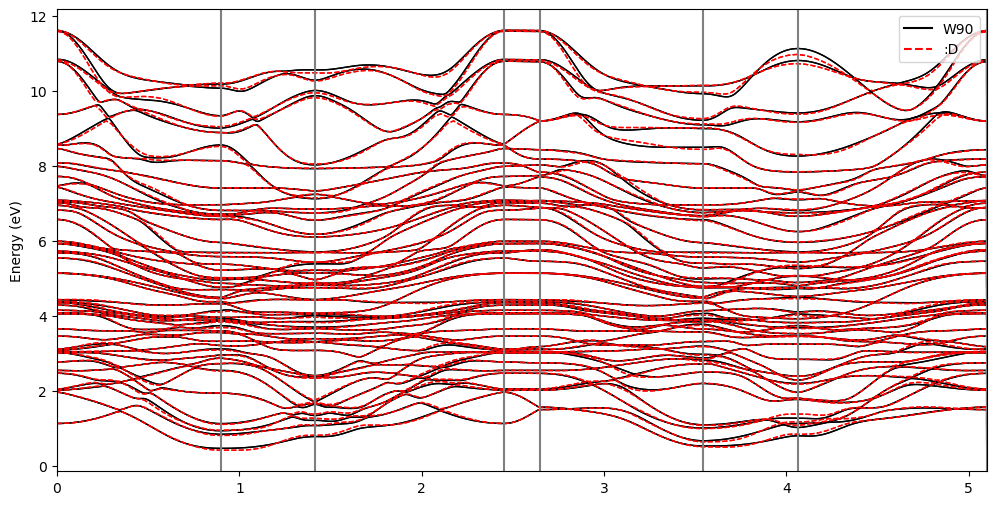

In [16]:
plt.figure(figsize=(12,6))
#plt.ylim(2.5,4)
#plt.xticks(Xmarks, Labels)
plt.xlim(0, 5.1)
plt.ylabel('Energy (eV)')
for b in bands_w90.T:
    plt.plot(x_w90, b, 'k', lw=1)

for b in bands.T:
    plt.plot(xx, b, 'r--', lw=1)
plt.plot([], [], 'k', label='W90')
plt.plot([], [], 'r--', label=':D')
for x in Xmarks:
    plt.axvline(x, color = 'gray')
plt.legend(loc='upper right')
plt.show()

In [17]:
(23.108 + 78.972)/2

51.04